# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within each band (`merge_lst_metacatalog`).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "I_*_deep_Taper_R0_*.fits"  or  ("*.fits", "*_LST*h_*.fits")
#FITS_GLOB: str | tuple[str, ...] = "*.fits"
FITS_GLOB = "??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coadd")  # Parquet catalog tree

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=7.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 93 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits']
LST hours from discovery (24): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h
LST hours in use (all discovered): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h


,path,lst_hour,band,time_key
0,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Blue,None
1,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Full,None
2,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,00h,Green,None
3,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,00h,Red,None
4,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,01h,Blue,None
...,...,...,...,...
88,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Blue,None
89,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Full,None
90,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,22h,Green,None
91,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,22h,Red,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "E_RA",
    "E_DEC",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "E_Maj",
    "Min",
    "E_Min",
    "PA",
    "E_PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "S_Code",
    "Gaus_id",
    "Isl_id",
    "Source_id",
    "Resid_Isl_rms",
    "Resid_Isl_mean",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


Cached ('00h', 'Blue'): 5401 sources <- sources_00h_Blue.parquet
Cached ('00h', 'Full'): 2772 sources <- sources_00h_Full.parquet
Cached ('00h', 'Green'): 2823 sources <- sources_00h_Green.parquet
Cached ('00h', 'Red'): 980 sources <- sources_00h_Red.parquet
Cached ('01h', 'Blue'): 5235 sources <- sources_01h_Blue.parquet
Cached ('01h', 'Full'): 2829 sources <- sources_01h_Full.parquet
Cached ('01h', 'Green'): 2992 sources <- sources_01h_Green.parquet
Cached ('01h', 'Red'): 1030 sources <- sources_01h_Red.parquet
Cached ('02h', 'Blue'): 5601 sources <- sources_02h_Blue.parquet
Cached ('02h', 'Full'): 2919 sources <- sources_02h_Full.parquet
Cached ('02h', 'Green'): 3057 sources <- sources_02h_Green.parquet
Cached ('02h', 'Red'): 1060 sources <- sources_02h_Red.parquet
Cached ('03h', 'Blue'): 5756 sources <- sources_03h_Blue.parquet
Cached ('03h', 'Full'): 2897 sources <- sources_03h_Full.parquet
Cached ('03h', 'Green'): 2979 sources <- sources_03h_Green.parquet
Cached ('03h', 'Red'): 1

## Metacatalog fusion

LST merge within each band, then sequential Full→Blue→Green→Red association
(`lwa_catalog.create.merge`). Band field lists and spectral-index inputs come from
`lwa_catalog.constants` (`BAND_FIELDS` includes `E_Total_flux` for `E_alpha_*`).


In [6]:
from lwa_catalog.constants import BAND_FIELDS

# BAND_FIELDS must include E_Total_flux so associated errors propagate into
# E_Total_flux_{band} and then E_alpha_RG / E_alpha_GB.
assert "E_Total_flux" in BAND_FIELDS


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (Full): loaded 9258 sources from metacatalog_lst_Full.parquet
LST merge (Blue): loaded 17982 sources from metacatalog_lst_Blue.parquet
LST merge (Green): loaded 9423 sources from metacatalog_lst_Green.parquet
LST merge (Red): loaded 3506 sources from metacatalog_lst_Red.parquet

Global metacatalog: 17800 sources from 238183 per-image detections
Wrote /fast/claw/metacatalog_coadd/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,0,Full,"Full,Blue,Green,Red",252.783208,4.988116,365.663162,300.599426,0.213967,0.171186,43.372883,...,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,0.052779,0.011854,-2.392619,0.005804
1,1,Full,"Full,Blue,Green,Red",139.523952,-12.107700,276.074222,208.307001,0.216689,0.211570,57.357736,...,1,0.225297,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.744078,0.010593,-2.870002,0.007441
2,2,Full,"Full,Blue,Green,Red",69.275337,29.672964,244.740156,374.459579,0.272094,0.201281,39.426515,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.722770,0.007104,-2.095139,0.004772
3,3,Full,"Full,Blue,Green,Red",260.126249,-0.997670,163.993429,149.756918,0.236393,0.185964,48.253414,...,2,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-2.362700,0.022025,-0.018238,0.016964
4,4,Full,"Full,Blue,Green,Red",6.347919,64.146244,154.178437,156.005577,0.235884,0.186792,46.465689,...,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.814845,0.016458,-0.462015,0.014339
5,5,Full,"Full,Blue,Green,Red",49.947681,41.505314,142.114649,111.084298,0.201799,0.151785,45.923001,...,1,0.230802,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-2.587868,0.012207,-0.313395,0.010596
6,6,Full,"Full,Blue,Green,Red",76.171778,38.099024,133.333919,97.259269,0.181262,0.140699,38.142203,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.773515,0.012985,-2.008041,0.009186
7,7,Full,"Full,Blue,Green,Red",303.611847,23.584427,115.830570,89.081987,0.204157,0.150832,41.565005,...,1,0.235147,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.948982,0.022014,-1.043338,0.013590
8,8,Full,"Full,Blue,Green,Red",123.400818,48.216455,107.472577,78.364744,0.196808,0.144914,40.760812,...,1,0.230177,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.754413,0.021678,-1.622645,0.013273
9,9,Full,"Full,Blue,Green,Red",284.113773,1.426594,107.244296,231.870395,0.373870,0.271229,155.960865,...,2,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.952585,0.033907,-1.194267,0.028853


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")
metacatalog.head(10)[["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "n_assoc_Blue", "n_assoc_Green", "n_assoc_Red"]]

Full-band sources after LST merge: 9258
  seen in multiple LST hours: 8295


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
2,69.275337,29.672964,244.740156,52,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
4,6.347919,64.146244,154.178437,46,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
1,139.523952,-12.107700,276.074222,43,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",09h
82,280.565578,79.772389,36.409813,42,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",19h
0,252.783208,4.988116,365.663162,41,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",17h
404,83.531344,22.081290,18.896768,39,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",06h
5,49.947681,41.505314,142.114649,37,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",03h
117,35.769238,86.313467,32.702211,36,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",02h
6,76.171778,38.099024,133.333919,36,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
55,319.592753,60.806127,43.499602,33,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",21h



Global rows by origin_band:
origin_band
Full     9258
Blue     8355
Green     144
Red        43
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 9157


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,0,252.783208,4.988116,Full,365.663162,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",6,2,1
1,1,139.523952,-12.107700,Full,276.074222,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",3,2,1
2,2,69.275337,29.672964,Full,244.740156,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
3,3,260.126249,-0.997670,Full,163.993429,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",2,2,2
4,4,6.347919,64.146244,Full,154.178437,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
5,5,49.947681,41.505314,Full,142.114649,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
6,6,76.171778,38.099024,Full,133.333919,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
7,7,303.611847,23.584427,Full,115.830570,"00h,01h,02h,14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1
8,8,123.400818,48.216455,Full,107.472577,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
9,9,284.113773,1.426594,Full,107.244296,"14h,15h,16h,17h,18h,19h,20h,21h",4,2,2


## Fit quality

Summarize detection fit quality on **`lst_merged`** (representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on a Full-band map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [9]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 1.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 1°).


In [10]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== Full: 9258 LST-merged sources ===
  Residual top-1%: union=137 (rms=94, |mean|=94; finite Resid_Isl_rms=9258)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
1110,350.113420,58.395651,11.411132,4.599297,3.821216,S
4613,311.919679,51.180799,5.232269,4.003123,5.276289,C
1068,350.573873,58.984994,11.570831,3.978722,2.164332,M
382,350.638178,58.900944,19.262825,3.978722,2.164332,M
1376,305.323849,45.745016,10.176018,3.812685,9.354512,S
231,309.648839,51.319933,24.724286,3.292976,3.901257,C
507,310.541591,50.487799,17.069645,3.292976,3.901257,M
897,311.828018,50.158091,12.745867,3.292976,3.901257,C
4367,311.538787,51.024281,5.416919,3.292976,3.901257,C
5014,312.358224,51.299733,4.966970,3.292976,3.901257,C


  Unphysical flux (σ < -3): 127


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
9256,-3267.240532,16.726337,-49.750126,0.000440,1.265887,0.000288,0.000259
7434,-135.140617,250.152190,32.164062,0.072044,3.822085,0.026784,0.007254
1,-114.119056,139.523952,-12.107700,208.307001,276.074222,0.489924,0.335570
9227,-102.105990,300.726032,-26.614313,0.058682,2.119421,0.008370,0.018365
0,-75.192108,252.783208,4.988116,300.599426,365.663162,0.728101,0.467561
9107,-72.640075,226.223168,46.402348,0.179751,2.814676,0.017803,0.031604
6,-72.636192,76.171778,38.099024,97.259269,133.333919,0.407278,0.284225
1596,-69.520883,44.938605,-50.971910,0.838453,9.385778,0.104506,0.064762
8524,-57.112584,250.074000,31.574875,0.248243,3.387404,0.046073,0.029973
128,-52.790562,350.569093,58.840346,12.634328,31.475390,0.265878,0.238092



=== Blue: 17982 LST-merged sources ===
  Residual top-1%: union=248 (rms=183, |mean|=180; finite Resid_Isl_rms=17982)


...


=== Red: 3506 LST-merged sources ===
  Residual top-1%: union=48 (rms=36, |mean|=36; finite Resid_Isl_rms=3506)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
735,324.144996,34.119606,22.212899,10.431501,18.146450,C
549,271.450598,-19.913592,25.744037,7.906175,3.838023,M
1710,270.281467,-20.727834,14.067905,7.906175,3.838023,M
3504,243.857419,46.430856,4.389627,6.973630,3.267864,M
3,139.527326,-12.104128,450.923314,6.011244,8.072760,S
12,284.121363,1.300604,216.366323,5.970198,4.942498,M
100,278.265704,-10.241680,62.210722,5.404422,15.644979,S
75,44.437282,6.036252,70.082639,5.374195,4.462672,S
322,67.272596,77.155455,33.455941,4.995132,4.789160,S
1534,270.824248,-27.738881,14.872674,4.953885,7.566233,C


  Unphysical flux (σ < -3): 9


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
3505,-34.519143,264.298197,37.208338,0.057762,3.046244,0.083611,0.022459
50,-17.169358,301.202569,41.880105,63.674724,89.333477,1.249716,0.819507
1276,-14.759836,261.351385,36.503764,9.207524,16.428373,0.486208,0.054225
113,-9.699973,350.440973,58.921296,38.209236,58.532686,1.697486,1.228182
219,-5.923275,350.524453,58.990715,30.886206,41.074083,1.452913,0.920518
244,-4.260992,260.284547,-0.982381,31.770350,38.841501,1.393390,0.901349
943,-3.801239,193.545445,27.623983,13.735300,19.358004,1.204475,0.858605
1770,-3.256458,300.149302,40.775665,9.228925,13.842922,1.134878,0.848287
3389,-3.149296,68.917222,29.186265,4.670079,8.503850,0.930453,0.784971



Stored per-band flags in fit_qa.


Densest 1° bins (Full):


,count,RA_center,DEC_center,i_ra,i_dec
0,8,299.5,40.5,299,93
1,7,350.5,58.5,350,111
2,7,187.5,12.5,187,65
3,6,305.5,40.5,305,93
4,5,94.5,22.5,94,75
5,5,269.5,-23.5,269,29
6,5,283.5,1.5,283,54
7,5,69.5,29.5,69,82
8,4,342.5,36.5,342,89
9,4,117.5,16.5,117,69


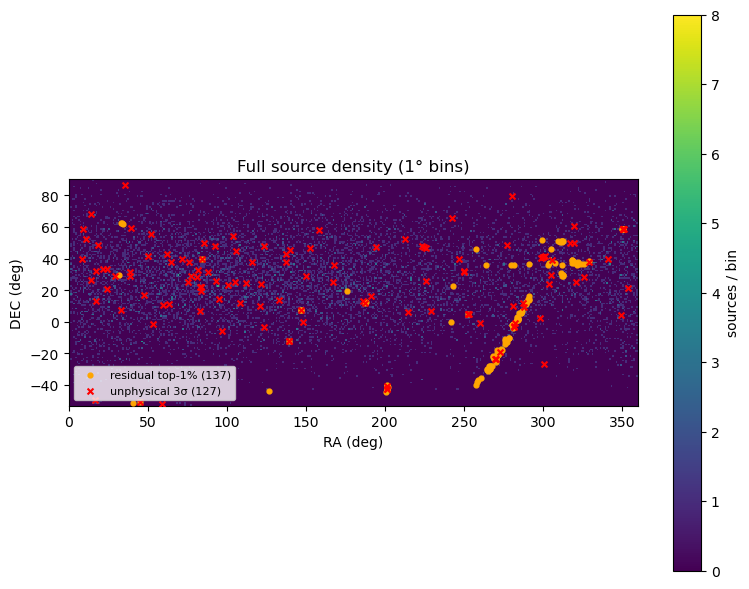


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,Full,9258,137,127,8,15
1,Blue,17982,248,190,14,64
2,Green,9423,154,38,7,12
3,Red,3506,48,9,4,4


In [11]:
import matplotlib.pyplot as plt

# Full-band 1° density map + flagged overlays; roll-up for all bands
primary_band = "Full" if "Full" in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)


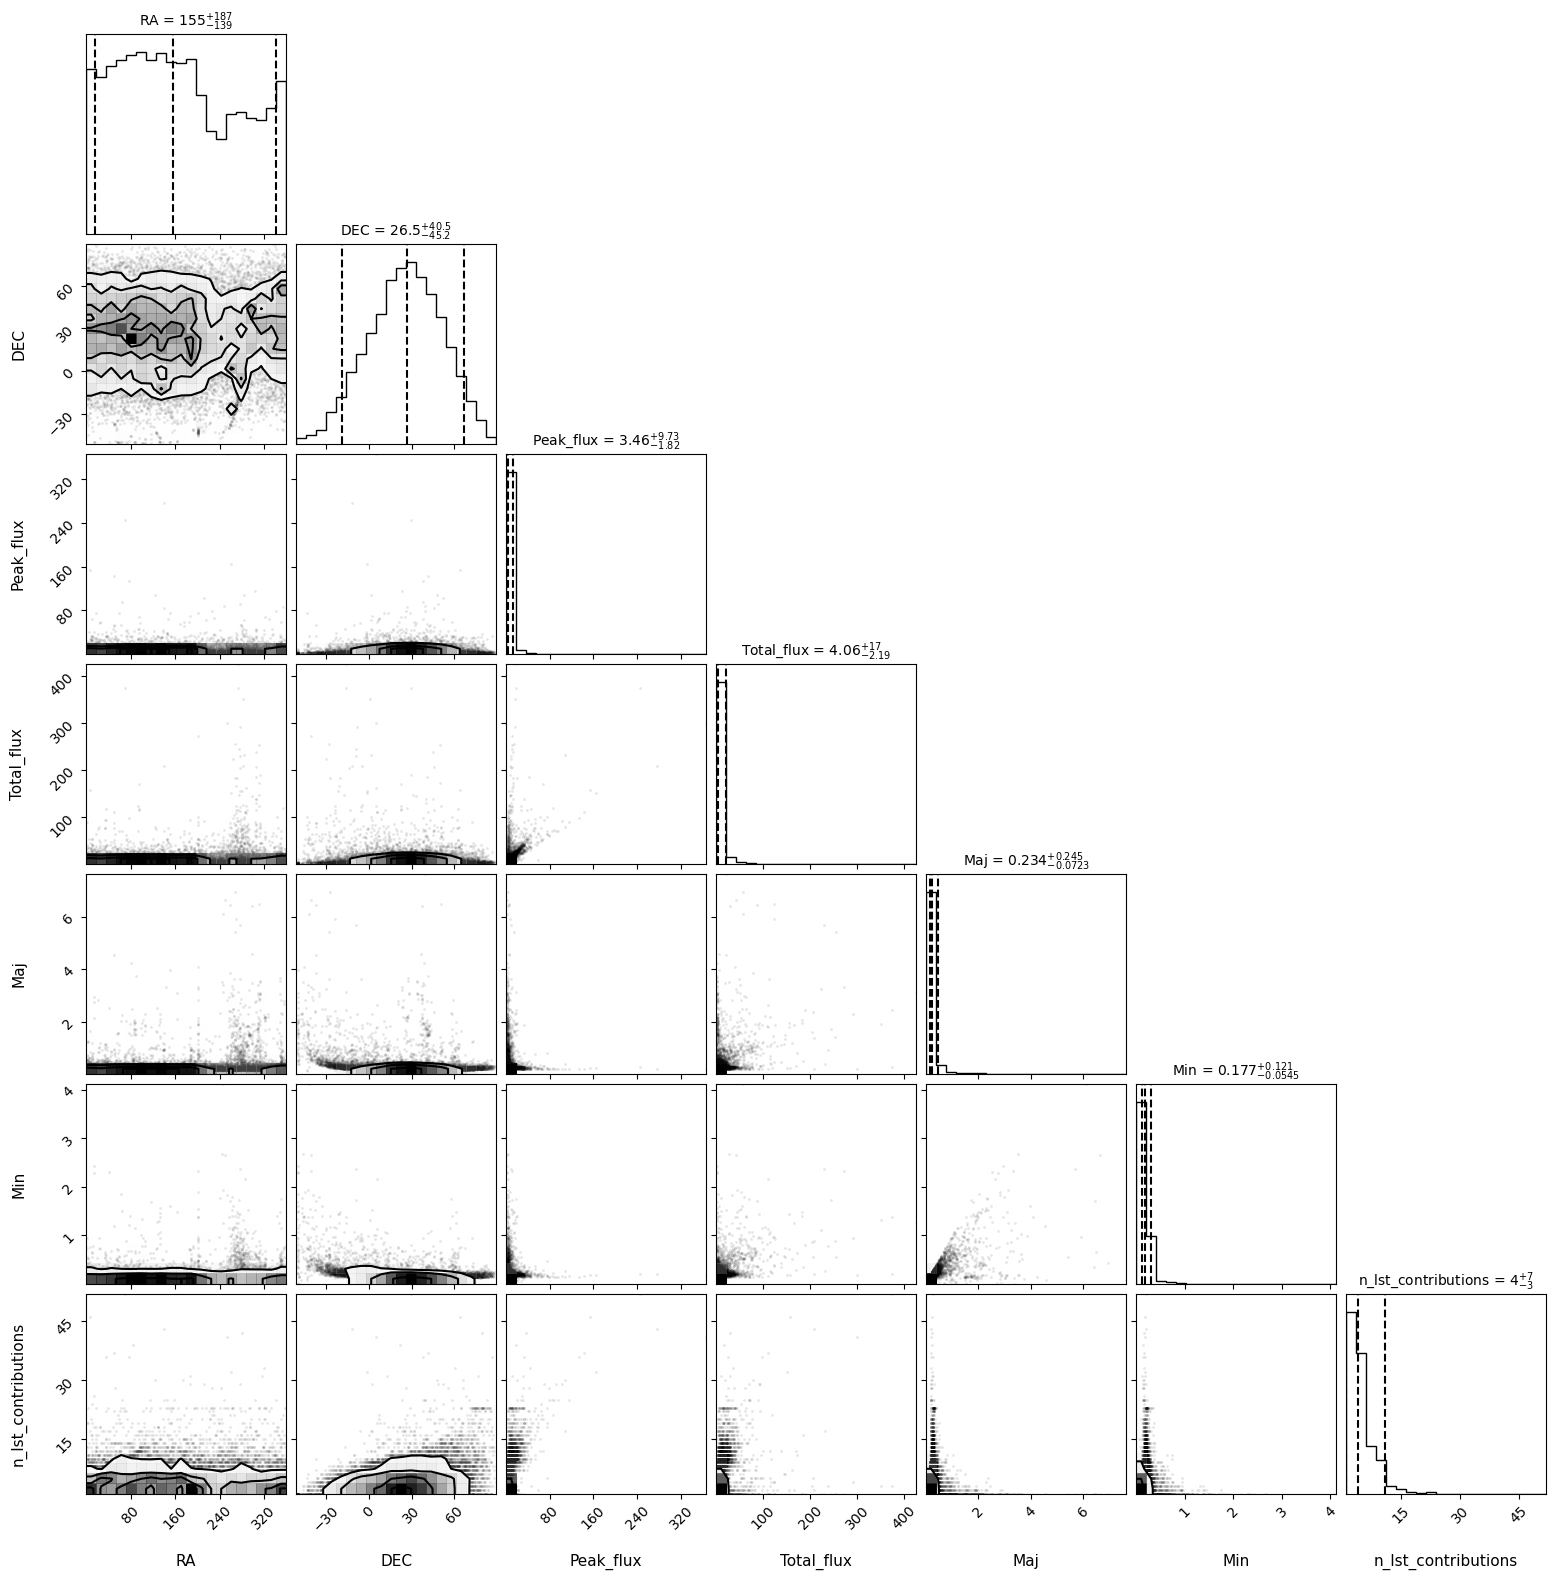

In [12]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


## Spectral index distribution

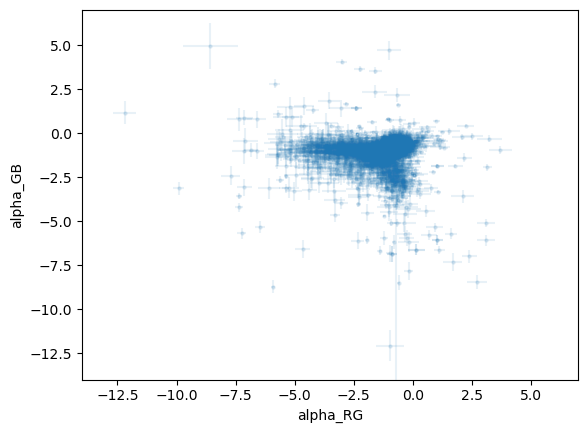

In [13]:
cols = ['meta_id', 'alpha_RG', 'E_alpha_RG', 'alpha_GB', 'E_alpha_GB']
data = metacatalog[cols].dropna(how='any')
ax = data.plot(x='alpha_RG', y='alpha_GB', xerr='E_alpha_RG', yerr='E_alpha_GB', marker='.', kind='scatter',
               alpha=0.1, xlim=[-14,7], ylim=[-14,7])
OUT_PNG = OUTPUT_DIR / "metacatalog_alpha.png"
ax.figure.savefig(OUT_PNG, dpi=150, bbox_inches="tight")

In [14]:
meta_ids = data[(data['alpha_RG']>1) & (data['alpha_GB']<-2)]['meta_id']

In [15]:
metacatalog.set_index('meta_id').loc[meta_ids].reset_index()

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,180,Full,"Full,Blue,Green,Red",269.908513,-23.589717,27.924319,114.198419,0.572164,0.553703,177.027027,...,1,0.233604,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.061152,0.140428,-3.322357,0.098309
1,781,Full,"Full,Blue,Green,Red",300.161195,40.601877,13.728145,24.930965,0.354723,0.217605,166.855592,...,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.402086,0.312484,-6.981352,0.369854
2,1688,Full,"Full,Blue,Green,Red",34.477010,62.051325,9.116973,93.191330,0.715393,0.606172,83.983709,...,1,0.227233,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.615637,0.240274,-5.709079,0.293554
3,1863,Full,"Full,Blue,Green,Red",0.020058,62.296537,8.678306,30.002409,0.530806,0.279737,41.771577,...,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.121161,0.229339,-6.618957,0.219012
4,1902,Full,"Full,Blue,Green,Red",175.810296,20.027701,8.577472,29.637038,0.472708,0.280148,74.528519,...,1,0.226146,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.042825,0.224429,-6.067560,0.265812
5,3107,Full,"Full,Blue,Green,Red",271.726901,-22.996091,6.541698,97.110695,1.870410,0.867131,36.411769,...,1,0.229482,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,3.100718,0.382016,-6.083677,0.323966
6,3320,Full,"Full,Blue,Green,Red",271.758222,-23.081079,6.293859,63.480005,0.969292,0.813047,168.937154,...,1,0.233604,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,3.100718,0.382016,-5.080950,0.222800
7,4582,Full,"Full,Blue,Green,Red",291.826736,18.018779,5.256444,85.119631,1.018824,0.632028,96.301088,...,1,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.703150,0.404387,-7.321875,0.527446
8,8068,Full,"Full,Blue,Green,Red",175.717895,19.999530,3.564035,7.618972,0.503769,0.256776,50.924576,...,1,0.223823,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.042825,0.224429,-6.067560,0.265812
9,8443,Full,"Full,Blue,Green,Red",105.128798,17.607072,3.422883,13.350348,0.556402,0.337608,65.057619,...,1,0.225297,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.124220,0.487180,-3.579457,0.360383
